## RPCA

In this notebook, RPCA is used for facial reconstruction of the occluded images. 

The difference between image reconstruction with a CNN Unet and RPCA is that RPCA does not use "training" with ground truth clear images in order to learn representation and apply it to unseen faces. 

RPCA functions as an unsupervised model. It does not use ground truth original images. The matrix fed into it consists of only training images with sparse occlusion, and the structure of faces is learned from redundancy from the parts of the images that aren't occluded. This is why for RPCA, it is important that occlusion is random across images and not occluding the same part of every image so that RPCA does not learn that the occlusion is part of the low rank face but instead recognizes it as sparse noise.
Then the learned subspace from the training images is applied to the testing occluded images to reconstruct them.
 

In [117]:
#import packages
import os
import imageio
import numpy as np
from sklearn.model_selection import train_test_split
import time
from numpy.linalg import norm, svd
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim


In [106]:
#import images (coppied from Unet improvements notebook)

# Create the array of image vectors. 

dataset_path = "CroppedYaleCopy/CroppedYale Project Data/CroppedYale"

images = [] # To store the images 
labels = [] # To store the labels. 

for subject in sorted(os.listdir(dataset_path)):
    
    subject_path = os.path.join(dataset_path, subject)
    
    if not os.path.isdir(subject_path):
        continue
        
    for file in os.listdir(subject_path):
        
        # Skip ambient images if any have been detected. 
        if "Ambient" in file:
            continue
            
        if file.endswith(".pgm"):
            
            path = os.path.join(subject_path, file)
            img = imageio.imread(path)
            
            images.append(img) # Append images. 
            labels.append(subject) # Append label to be the number of the person whose image it is. 

X = np.array(images) # Comvert to array.
y = np.array(labels) # Convert labels to array

print("Dataset shape:", X.shape)

/tmp/ipykernel_1150/710943570.py:26: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(path)


Dataset shape: (2414, 192, 168)


In [107]:
#normalize the image vectors in the same way as with U-net 

X = X.astype("float32") 
X = (X - X.min()) / (X.max() - X.min()) 
print(X.shape)

(2414, 192, 168)


In [108]:
#randomly occlude images in the same way as UNET

# Here we generate the occlusions and masks:

np.random.seed(42)   # we use this same random seed in all experiments to get identical masks

N, H, W = X.shape

X_occluded = X.copy()
masks = np.zeros_like(X)

for i in range(N):

    # generate random masks of size 15–30% of image size
    mask_h = np.random.randint(int(H * 0.15), int(H * 0.30))
    mask_w = np.random.randint(int(W * 0.15), int(W * 0.30))

    # generate random position to insert the mask.
    y = np.random.randint(0, H - mask_h)
    x = np.random.randint(0, W - mask_w)

    # apply mask to images. 
    X_occluded[i, y:y+mask_h, x:x+mask_w] = 0
    masks[i, y:y+mask_h, x:x+mask_w] = 1

print("Occluded dataset shape:", X_occluded.shape)
print("2414 images of dimension 192 by 168")

Occluded dataset shape: (2414, 192, 168)
2414 images of dimension 192 by 168


In [109]:
# For UNet, we add channels. for RPCA, we flatten each 2D image into a 1D vector.
# The shape of the dataset will become (2414, 32256) (each row is an image)

X_occluded = X_occluded.reshape((X.shape[0], X.shape[1] * X.shape[2]))


#X_occluded = X_occluded.T
print(X_occluded.shape)

(2414, 32256)


In [115]:
# Train and Test splits:
X_train_occ, X_test_occ, X_train_clean, X_test_clean, X_train_masks, X_test_masks = train_test_split(
    X_occluded,
    X,
    masks,
    test_size=0.2,
    random_state=42
)
print(X_train_occ.shape, X_test_occ.shape)

#RPCA expects shape with each column being an image. 
#Currently they are images as rows, so transpose

X_train_occ = X_train_occ.T
X_test_occ = X_test_occ.T
print("Transposed shape:",X_train_occ.shape, X_test_occ.shape) #1931 images for training, 483 for testing

print("x_test_clean:",X_test_clean.shape)
X_train_clean = X_train_clean.T

(1931, 32256) (483, 32256)
Transposed shape: (32256, 1931) (32256, 483)
x_test_clean: (483, 192, 168)


In [ ]:
#RPCA function

# http://kastnerkyle.github.io/posts/robust-matrix-decomposition/

def inexact_augmented_lagrange_multiplier(X, lmbda=.01, tol=1e-3,
                                          maxiter=100, verbose=True):
    """
    Inexact Augmented Lagrange Multiplier
    """
    Y = X
    norm_two = norm(Y.ravel(), 2)
    norm_inf = norm(Y.ravel(), np.inf) / lmbda
    dual_norm = np.max([norm_two, norm_inf])
    Y = Y / dual_norm
    A = np.zeros(Y.shape)
    E = np.zeros(Y.shape)
    dnorm = norm(X, 'fro')
    mu = 1.25 / norm_two
    rho = 1.5
    sv = 10.
    n = Y.shape[0]
    itr = 0
    while True:
        Eraw = X - A + (1 / mu) * Y
        Eupdate = np.maximum(Eraw - lmbda / mu, 0) + np.minimum(Eraw + lmbda / mu, 0)
        U, S, V = svd(X - Eupdate + (1 / mu) * Y, full_matrices=False)
        svp = (S > 1 / mu).shape[0]
        if svp < sv:
            sv = np.min([svp + 1, n])
        else:
            sv = np.min([svp + round(.05 * n), n])
        Aupdate = np.dot(np.dot(U[:, :svp], np.diag(S[:svp] - 1 / mu)), V[:svp, :])
        A = Aupdate
        E = Eupdate
        Z = X - A - E
        Y = Y + mu * Z
        mu = np.min([mu * rho, mu * 1e7])
        itr += 1
        if ((norm(Z, 'fro') / dnorm) < tol) or (itr >= maxiter):
            break
    if verbose:
        print("Finished at iteration %d" % (itr))  
    return A, E

In [15]:
### seeing if this version of the function will be faster
def inexact_augmented_lagrange_multiplier(X, lmbda=.01, tol=1e-3,
                                          maxiter=100, verbose=True):
    """
    Inexact Augmented Lagrange Multiplier
    """
    from sklearn.utils.extmath import randomized_svd
    Y = X
    norm_two = norm(Y.ravel(), 2)
    norm_inf = norm(Y.ravel(), np.inf) / lmbda
    dual_norm = np.max([norm_two, norm_inf])
    Y = Y / dual_norm
    A = np.zeros(Y.shape)
    E = np.zeros(Y.shape)
    dnorm = norm(X, 'fro')
    mu = 1.25 / norm_two
    rho = 1.5
    sv = 10.
    n = Y.shape[0]
    itr = 0
    while True:
        Eraw = X - A + (1 / mu) * Y
        Eupdate = np.maximum(Eraw - lmbda / mu, 0) + np.minimum(Eraw + lmbda / mu, 0)
        U, S, V = randomized_svd(  X - Eupdate + (1/mu)*Y,  n_components=50)
        svp = (S > 1 / mu).shape[0]
        if svp < sv:
            sv = np.min([svp + 1, n])
        else:
            sv = np.min([svp + round(.05 * n), n])
        Aupdate = np.dot(np.dot(U[:, :svp], np.diag(S[:svp] - 1 / mu)), V[:svp, :])
        A = Aupdate
        E = Eupdate
        Z = X - A - E
        Y = Y + mu * Z
        mu = np.min([mu * rho, mu * 1e7])
        itr += 1
        if ((norm(Z, 'fro') / dnorm) < tol) or (itr >= maxiter):
            break
    if verbose:
        print("Finished at iteration %d" % (itr))  
    return A, E


In [16]:
start_train = time.time()
L, S = inexact_augmented_lagrange_multiplier(X_train_occ)
#L is the low rank feature matrix, and S is the sparse noise matrix.
end_train = time.time()
print ("Time elapsed for robust PCA:", end_train - start_train, "s")

Finished at iteration 22
Time elapsed for robust PCA: 381.2065255641937 s


In [32]:
start_train = time.time()
#each image in L was a column but PCA expects images = rows, so transpose.
L_T = L.T

#fit PCA on L
pca = PCA(n_components = 150)
pca.fit(L_T) #creates new basis of components to represent the clean faces
end_train = time.time()
print ("Time elapsed for robust PCA:", end_train - start_train, "s")

Time elapsed for robust PCA: 78.80724215507507 s


In [143]:
print(L_T.shape)
X_test_occ = X_test_occ.T
X_test_occ.shape

(1931, 32256)


(483, 32256)

In [144]:
#do the same transpose for occluded images to go to shape (483, 32256)

print(X_test_occ.shape)
#project occluded test set onto learned clean face basis
X_test_occ_reduced = pca.transform(X_test_occ)

#reconstruc images
X_test_recon = pca.inverse_transform(X_test_occ_reduced)
print(X_test_recon.shape)


(483, 32256)
(483, 32256)


In [120]:
#check shapes:
#shapes will need to be (483, 192, 168) (483 images, height 192, width 168 each)
 
print("X_test_clean shape:",X_test_clean.shape) 

print("X_test_recon shape:", X_test_recon.shape)

print("X_test_occ shape:",X_test_occ.shape)

X_test_clean shape: (483, 192, 168)
X_test_recon shape: (483, 32256)
X_test_occ shape: (32256, 483)


(192, 168) (192, 168) (192, 168)


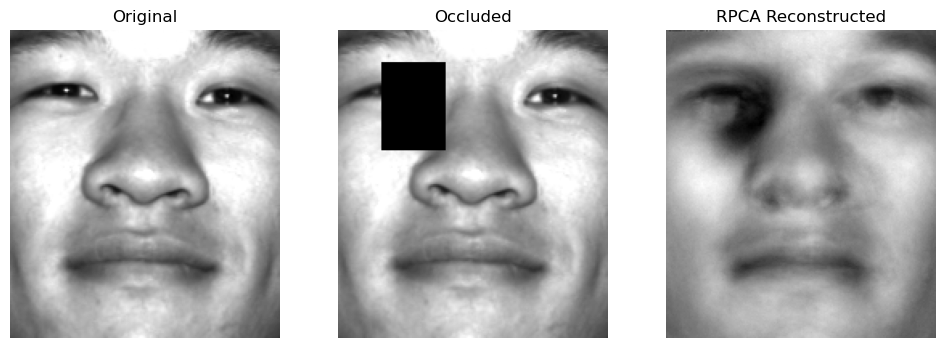

In [71]:
#visualize occluded face with reconstructed faces

idx = 0  # choose test image index


clean = X_test_clean[idx] #already in image format
occ = X_test_occ[idx].reshape(192,168) #reshape to image
recon = X_test_recon[idx].reshape(192,168) #reshape to image
print(clean.shape, occ.shape, recon.shape)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(clean, cmap='gray')
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Occluded")
plt.imshow(occ, cmap='gray')
plt.axis("off")

plt.subplot(1,3,3)
plt.title("RPCA Reconstructed")
plt.imshow(recon, cmap='gray')
plt.axis("off")

plt.show()

In [126]:
print(len(X_test_occ.T))

483


In [129]:
# Get all the evaluation metrics we are going to use to compare the reconstruction by the models: 

mse_total = 0
mae_total = 0
num_pixels = 0
ssim_scores = []

for i in range(len(X_test_occ.T)):

    clean = X_test_clean[i]
    occ = X_test_occ[i]
    recon = X_test_recon[i].reshape(192,168)
    mask = X_test_masks[i]
    
    masked_pixels = np.sum(masks) # This gives the number of pixels that are inside the mask only. 
    num_pixels += masked_pixels
    if masked_pixels == 0: # Check for incase there was no mask in the image passed. 
            continue

    # Calculate the error in only the mask area. 
    # Again, mask pixels are represented as 1 so this is only getting the error for those pixels.
    diff = (recon - clean) * mask 

        # MSE
    mse_total += np.sum(diff ** 2) # Calculate the mean squared error. 

        # MAE
    
    mae_total += np.sum(np.abs(diff))# Calculate the mean absolute error. 

        # SSIM : Structural Similarity Index. It compares luminance, contrast, and structure.
        # unlike the other metrics, SSIM is being calculated for the entire image, not just the mask.
        # This is because we are using SSIM as a measure for perceptual similiarty of the image as a whole
        # to compare it to how humans would perceive the image. 

        # Convert the reconstructed image to numpy array: 
    for i in range(recon.shape[0]):
        recon_img = recon.reshape(192,168)
        clean_img = clean.reshape(192,168)
        # Append SSIM score. The higher the better. 
        ssim_scores.append(ssim(clean_img, recon_img, data_range=1.0))

# Final metrics
mse = mse_total / masked_pixels # Average the squared error over the number of pixels. 
mae = mae_total / masked_pixels # Average the absolute error over the number of pixels. 
psnr = 10 * np.log10(1 / mse) # Calculate the peak signal-to-noise ratio. The higher the better reconstruction. 
ssim_score = np.mean(ssim_scores) # Average the SSIM scores. 

print("MSE:", mse)
print("MAE:", mae)
print("PSNR:", psnr)
print("SSIM:", ssim_score)

MSE: 0.013953793782293774
MAE: 0.03856281570896314
PSNR: 18.55307699579153
SSIM: 0.6202136637648569


In [138]:
idx = 0

inside_error = np.mean(diff**2)
outside_error = np.mean((diff/mask * (1-mask))**2)

print("Error inside mask:", inside_error)
print("Error outside mask:", outside_error)
#nans indicate possible bug in masked errors calculation according to chat?

Error inside mask: 0.0026073730219740372
Error outside mask: nan


/tmp/ipykernel_1150/3533499140.py:4: RuntimeWarning: divide by zero encountered in divide
  outside_error = np.mean((diff/mask * (1-mask))**2)
/tmp/ipykernel_1150/3533499140.py:4: RuntimeWarning: invalid value encountered in divide
  outside_error = np.mean((diff/mask * (1-mask))**2)


In [ ]:
#suggested fix
inside_error = np.mean((recon[mask==1] - clean[mask==1])**2)
outside_error = np.mean((recon[mask==0] - clean[mask==0])**2)